# Core Data Types (market/data_types.py)

In [26]:
"""
Market data types based on Investopedia references:
- Level 1: Best bid/ask, spread, mid
- Level 2: Order book depth (top N levels)
- Orders: Limit, Market, Cancel actions
"""

from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict, Any
from enum import Enum, auto
from datetime import datetime


class OrderType(Enum):
    """From Investopedia: Types of orders"""
    LIMIT = auto()      # Place_Limit order
    MARKET = auto()     # Place_Market order
    CANCEL = auto()     # Cancel existing order


class OrderSide(Enum):
    """Buy or Sell side"""
    BUY = auto()
    SELL = auto()


@dataclass(frozen=True)  # Immutable for thread-safety and integrity
class LimitOrder:
    """
    Limit Order definition based on Investopedia:
    - Price-specific order
    - May not execute if price not available
    - Adds liquidity to the market
    """
    order_id: str
    agent_id: str
    side: OrderSide
    price: float
    quantity: int
    timestamp: datetime = field(default_factory=datetime.now)

    def __post_init__(self):
        """Validate order parameters"""
        if self.price <= 0:
            raise ValueError("Price must be positive")
        if self.quantity <= 0:
            raise ValueError("Quantity must be positive")


@dataclass(frozen=True)
class MarketOrder:
    """
    Market Order definition based on Investopedia:
    - Execute immediately at best available price
    - Takes liquidity from the market
    - Price not guaranteed (slippage possible)
    """
    order_id: str
    agent_id: str
    side: OrderSide
    quantity: int
    timestamp: datetime = field(default_factory=datetime.now)


@dataclass(frozen=True)
class CancelOrder:
    """
    Cancel Order definition:
    - Request to cancel existing limit order
    - Must reference valid order_id
    """
    order_id: str  # ID of order to cancel
    agent_id: str
    timestamp: datetime = field(default_factory=datetime.now)


@dataclass(frozen=True)
class MarketSnapshot:
    """
    Level 1 & Level 2 Market Data based on Investopedia definitions:

    Level 1 (Essential):
    - Best bid/ask prices
    - Spread and mid-price
    - Last trade price

    Level 2 (Optional Depth):
    - Order book depth for price discovery
    - Market liquidity assessment
    """
    # Level 1 Data
    best_bid: Optional[float]  # Highest buy price
    best_ask: Optional[float]  # Lowest sell price
    last_price: Optional[float]  # Last traded price
    timestamp: datetime

    # Level 2 Data (Top N levels)
    bid_depth: List[Tuple[float, int]]  # [(price, quantity), ...]
    ask_depth: List[Tuple[float, int]]  # [(price, quantity), ...]

    # Derived properties
    @property
    def spread(self) -> Optional[float]:
        """Bid-ask spread (absolute)"""
        if self.best_bid is not None and self.best_ask is not None:
            return self.best_ask - self.best_bid
        return None

    @property
    def mid_price(self) -> Optional[float]:
        """Mid-point between bid and ask"""
        if self.best_bid is not None and self.best_ask is not None:
            return (self.best_bid + self.best_ask) / 2
        return None

    @property
    def is_market_open(self) -> bool:
        """Check if market has liquidity"""
        return self.best_bid is not None and self.best_ask is not None

    def get_depth_at_level(self, level: int, side: OrderSide) -> Optional[Tuple[float, int]]:
        """Get price and quantity at specified depth level"""
        depth = self.bid_depth if side == OrderSide.BUY else self.ask_depth
        if 0 <= level < len(depth):
            return depth[level]
        return None


@dataclass
class Action:
    """
    Agent's intent/action to be processed by the exchange.
    This is the ONLY way agents interact with the market.
    """
    order_type: OrderType
    order_data: Optional[Any] = None  # LimitOrder, MarketOrder, or CancelOrder

    @classmethod
    def place_limit_order(cls, agent_id: str, side: OrderSide,
                         price: float, quantity: int) -> 'Action':
        """Factory method for limit orders"""
        order = LimitOrder(
            order_id=f"LO_{agent_id}_{datetime.now().timestamp()}",
            agent_id=agent_id,
            side=side,
            price=price,
            quantity=quantity
        )
        return cls(order_type=OrderType.LIMIT, order_data=order)

    @classmethod
    def place_market_order(cls, agent_id: str, side: OrderSide,
                          quantity: int) -> 'Action':
        """Factory method for market orders"""
        order = MarketOrder(
            order_id=f"MO_{agent_id}_{datetime.now().timestamp()}",
            agent_id=agent_id,
            side=side,
            quantity=quantity
        )
        return cls(order_type=OrderType.MARKET, order_data=order)

    @classmethod
    def cancel_order(cls, agent_id: str, order_id: str) -> 'Action':
        """Factory method for cancel orders"""
        order = CancelOrder(
            order_id=order_id,
            agent_id=agent_id
        )
        return cls(order_type=OrderType.CANCEL, order_data=order)

    @classmethod
    def no_op(cls) -> 'Action':
        """No operation - agent chooses to do nothing"""
        return cls(order_type=None, order_data=None)

# Abstract Base Agent (agents/base.py)

In [27]:
"""
Agent Base Class using Python's ABC module.
Enforces polymorphism and consistent interface across all agent types.
"""

from abc import ABC, abstractmethod
from typing import Optional, Dict, Any
from dataclasses import dataclass, field
import uuid


@dataclass
class AgentState:
    """Private state of an agent - inaccessible to other agents"""
    balance: float = 0.0  # Cash balance
    inventory: int = 0    # Asset holdings
    active_orders: Dict[str, Any] = field(default_factory=dict)  # Agent's open orders

    def can_afford_buy(self, price: float, quantity: int) -> bool:
        """Check if agent has enough cash to buy"""
        return self.balance >= price * quantity

    def can_afford_sell(self, quantity: int) -> bool:
        """Check if agent has enough inventory to sell"""
        return self.inventory >= quantity

    def update_after_trade(self, side: str, price: float, quantity: int):
        """Update state after trade execution"""
        if side == "BUY":
            self.balance -= price * quantity
            self.inventory += quantity
        else:  # SELL
            self.balance += price * quantity
            self.inventory -= quantity

    def add_order(self, order_id: str, order_details: Dict[str, Any]):
        """Track active order"""
        self.active_orders[order_id] = order_details

    def remove_order(self, order_id: str):
        """Remove completed/cancelled order"""
        self.active_orders.pop(order_id, None)


class Agent(ABC):
    """
    Abstract Base Class for all trading agents.

    Based on Agent-Based Modeling principles:
    1. Autonomous decision-making
    2. Bounded rationality (limited information)
    3. Message-sending process (orders as messages)
    4. Polymorphic interface (same method, different implementations)

    Design Principles:
    - Agents ONLY see market snapshots (no future info)
    - Agents CANNOT directly mutate market state
    - Agents emit intents (Actions) processed by exchange
    - Complete separation of decision logic from market mechanics
    """

    def __init__(self, agent_id: Optional[str] = None,
                 initial_balance: float = 10000.0,
                 initial_inventory: int = 100):
        """
        Initialize agent with private state.

        Args:
            agent_id: Unique identifier (auto-generated if None)
            initial_balance: Starting cash balance
            initial_inventory: Starting asset holdings
        """
        self.agent_id = agent_id or f"agent_{uuid.uuid4().hex[:8]}"
        self._state = AgentState(
            balance=initial_balance,
            inventory=initial_inventory
        )
        self._metadata = {
            "creation_time": datetime.now(),
            "trades_executed": 0,
            "orders_placed": 0
        }

    @property
    def state(self) -> AgentState:
        """
        Read-only access to agent state.
        Using property to prevent external mutation.
        """
        # Return a copy to prevent external modification
        import copy
        return copy.copy(self._state)

    @abstractmethod
    def get_action(self, market_snapshot: 'MarketSnapshot') -> 'Action':
        """
        Abstract method that ALL agents must implement.

        This is the core decision-making function where:
        1. Agent observes current market state (L1/L2 data only)
        2. Agent makes trading decision based on its strategy
        3. Agent returns an Action (or no-op)

        Args:
            market_snapshot: Current market state (immutable)

        Returns:
            Action: Trading intent to be processed by exchange
        """
        pass

    def receive_trade_confirmation(self, trade_details: Dict[str, Any]):
        """
        Callback from exchange when agent's order is executed.
        Updates agent's private state.

        This method is called by the exchange, NOT by the agent itself.
        """
        # Update balance and inventory
        self._state.update_after_trade(
            side=trade_details['side'],
            price=trade_details['price'],
            quantity=trade_details['quantity']
        )

        # Remove order from active orders if it's a market order
        # or if limit order is fully filled
        order_id = trade_details.get('order_id')
        if order_id and order_id in self._state.active_orders:
            current_qty = self._state.active_orders[order_id].get('remaining_quantity', 0)
            traded_qty = trade_details['quantity']

            if current_qty <= traded_qty:
                self._state.remove_order(order_id)
            else:
                # Partial fill - update remaining quantity
                self._state.active_orders[order_id]['remaining_quantity'] = current_qty - traded_qty

        # Update metadata
        self._metadata['trades_executed'] += 1

    def receive_order_confirmation(self, order_id: str,
                                  status: str, details: Dict[str, Any]):
        """
        Callback from exchange when order is accepted/rejected.
        """
        if status == 'ACCEPTED':
            self._state.add_order(order_id, details)
            self._metadata['orders_placed'] += 1
        elif status == 'REJECTED':
            # Log rejection reason if needed
            pass

    def receive_cancel_confirmation(self, order_id: str,
                                   status: str, details: Dict[str, Any]):
        """
        Callback from exchange when cancel request is processed.
        """
        if status == 'CANCELLED':
            self._state.remove_order(order_id)

    def get_performance_metrics(self) -> Dict[str, Any]:
        """
        Get agent's performance metrics.
        Useful for analysis and visualization.
        """
        portfolio_value = (self._state.balance +
                          self._state.inventory * self._state.get('last_price', 0))

        return {
            'agent_id': self.agent_id,
            'agent_type': self.__class__.__name__,
            'balance': self._state.balance,
            'inventory': self._state.inventory,
            'portfolio_value': portfolio_value,
            'trades_executed': self._metadata['trades_executed'],
            'orders_placed': self._metadata['orders_placed'],
            'active_orders': len(self._state.active_orders)
        }

    def __str__(self):
        """String representation for debugging"""
        return (f"{self.__class__.__name__}(id={self.agent_id}, "
                f"balance={self._state.balance:.2f}, "
                f"inventory={self._state.inventory})")

# Random Agent Implementation (agents/random_agent.py)

# 1. Setup and Imports

In [28]:
# Install necessary packages for Google Colab
!pip install dataclasses-json numpy matplotlib typing_extensions

# Core imports
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from enum import Enum, auto
from typing import Dict, List, Optional, Tuple, Any, NamedTuple
import random
from datetime import datetime
import numpy as np
from typing_extensions import Protocol
import json
from dataclasses_json import dataclass_json

# 2. Core Data Structures

In [29]:
class OrderType(Enum):
    """Types of orders agents can place"""
    LIMIT = auto()
    MARKET = auto()

class OrderSide(Enum):
    """Buy or sell side"""
    BUY = auto()
    SELL = auto()

class ActionType(Enum):
    """Types of actions agents can take"""
    PLACE_LIMIT = auto()
    PLACE_MARKET = auto()
    CANCEL = auto()
    NO_OP = auto()

@dataclass_json
@dataclass
class OrderBookEntry:
    """Single entry in the order book"""
    price: float
    quantity: int
    order_id: str = ""
    timestamp: float = 0.0

@dataclass_json
@dataclass
class Level1Data:
    """Level 1 market data - visible to all agents"""
    timestamp: float
    best_bid: float
    best_ask: float
    bid_quantity: int
    ask_quantity: int
    last_price: Optional[float] = None
    last_quantity: Optional[int] = None

    @property
    def spread(self) -> float:
        """Calculate the bid-ask spread"""
        return self.best_ask - self.best_bid

    @property
    def mid_price(self) -> float:
        """Calculate the mid price"""
        return (self.best_bid + self.best_ask) / 2

    @property
    def spread_bps(self) -> float:
        """Calculate spread in basis points"""
        return (self.spread / self.mid_price) * 10000 if self.mid_price > 0 else 0

@dataclass_json
@dataclass
class Level2Data:
    """Level 2 market data - optional depth information"""
    timestamp: float
    bids: List[OrderBookEntry] = field(default_factory=list)
    asks: List[OrderBookEntry] = field(default_factory=list)

    def get_top_n(self, n: int = 5) -> Tuple[List[OrderBookEntry], List[OrderBookEntry]]:
        """Get top N levels from both sides"""
        return self.bids[:n], self.asks[:n]

@dataclass_json
@dataclass
class MarketSnapshot:
    """Complete market snapshot provided to agents"""
    timestamp: float
    level1: Level1Data
    level2: Optional[Level2Data] = None
    order_book_id: Optional[str] = None

    def __post_init__(self):
        """Validate the snapshot"""
        if self.level1.best_ask <= self.level1.best_bid:
            raise ValueError("Best ask must be greater than best bid")

# 3. Agent Actions

In [30]:
from typing import Optional, Union, Dict, Any, List
from enum import Enum, auto
from dataclasses import dataclass, field
from dataclasses_json import dataclass_json
import random
import numpy as np
from datetime import datetime

# Re-defining enums to ensure they're available
class OrderSide(Enum):
    """Buy or sell side"""
    BUY = auto()
    SELL = auto()

class ActionType(Enum):
    """Types of actions agents can take"""
    PLACE_LIMIT = auto()
    PLACE_MARKET = auto()
    CANCEL = auto()
    NO_OP = auto()

@dataclass_json
@dataclass
class Action:
    """
    Unified Action class using discriminated union pattern.
    All agent actions are instances of this class.
    """
    action_type: ActionType
    agent_id: str
    timestamp: float
    order_id: Optional[str] = None

    # Fields for specific action types
    side: Optional[OrderSide] = None
    price: Optional[float] = None
    quantity: Optional[int] = None

    def __post_init__(self):
        """Validate action based on type"""
        if self.action_type == ActionType.PLACE_LIMIT:
            if self.side is None:
                raise ValueError("Side must be specified for limit orders")
            if self.price is None or self.price <= 0:
                raise ValueError("Price must be positive for limit orders")
            if self.quantity is None or self.quantity <= 0:
                raise ValueError("Quantity must be positive for limit orders")

        elif self.action_type == ActionType.PLACE_MARKET:
            if self.side is None:
                raise ValueError("Side must be specified for market orders")
            if self.quantity is None or self.quantity <= 0:
                raise ValueError("Quantity must be positive for market orders")

        elif self.action_type == ActionType.CANCEL:
            if not self.order_id:
                raise ValueError("Order ID must be provided for cancel action")

    @classmethod
    def create_limit_order(cls, agent_id: str, timestamp: float,
                          side: OrderSide, price: float, quantity: int,
                          order_id: Optional[str] = None) -> 'Action':
        """Factory method for creating limit orders"""
        return cls(
            action_type=ActionType.PLACE_LIMIT,
            agent_id=agent_id,
            timestamp=timestamp,
            order_id=order_id,
            side=side,
            price=price,
            quantity=quantity
        )

    @classmethod
    def create_market_order(cls, agent_id: str, timestamp: float,
                           side: OrderSide, quantity: int,
                           order_id: Optional[str] = None) -> 'Action':
        """Factory method for creating market orders"""
        return cls(
            action_type=ActionType.PLACE_MARKET,
            agent_id=agent_id,
            timestamp=timestamp,
            order_id=order_id,
            side=side,
            quantity=quantity
        )

    @classmethod
    def create_cancel_order(cls, agent_id: str, timestamp: float,
                           order_id: str) -> 'Action':
        """Factory method for creating cancel orders"""
        return cls(
            action_type=ActionType.CANCEL,
            agent_id=agent_id,
            timestamp=timestamp,
            order_id=order_id
        )

    @classmethod
    def create_no_op(cls, agent_id: str, timestamp: float,
                    order_id: Optional[str] = None) -> 'Action':
        """Factory method for creating no-op actions"""
        return cls(
            action_type=ActionType.NO_OP,
            agent_id=agent_id,
            timestamp=timestamp,
            order_id=order_id
        )

    def to_dict(self) -> Dict[str, Any]:
        """Convert action to dictionary"""
        result = {
            'action_type': self.action_type.name,
            'agent_id': self.agent_id,
            'timestamp': self.timestamp,
            'order_id': self.order_id
        }

        if self.side is not None:
            result['side'] = self.side.name
        if self.price is not None:
            result['price'] = self.price
        if self.quantity is not None:
            result['quantity'] = self.quantity

        return result

    def __str__(self) -> str:
        if self.action_type == ActionType.PLACE_LIMIT:
            return (f"PlaceLimitOrder(agent={self.agent_id}, side={self.side.name}, "
                   f"price={self.price}, quantity={self.quantity})")
        elif self.action_type == ActionType.PLACE_MARKET:
            return (f"PlaceMarketOrder(agent={self.agent_id}, side={self.side.name}, "
                   f"quantity={self.quantity})")
        elif self.action_type == ActionType.CANCEL:
            return f"CancelOrder(agent={self.agent_id}, order_id={self.order_id})"
        else:
            return f"NoOp(agent={self.agent_id})"

# 4. Abstract Base Class Implementation

In [31]:
class Agent(ABC):
    """
    Abstract Base Class for all trading agents.

    Implements the core principles from:
    1. Python abc module - enforce interface consistency
    2. ABM literature - agents as autonomous decision-makers
    3. Market microstructure - limited information access

    Key Design Decisions:
    - Agents see only current market state, not future
    - Agents cannot directly mutate market state
    - Agents maintain private state (balance, inventory)
    - All communication is through action emission
    """

    def __init__(self, agent_id: str, initial_balance: float = 10000.0):
        """
        Initialize agent with unique ID and initial balance.

        Args:
            agent_id: Unique identifier for the agent
            initial_balance: Starting cash balance
        """
        self._id = agent_id
        self._balance = initial_balance
        self._inventory = 0  # Positive = long, Negative = short
        self._position_value = 0.0
        self._open_orders: Dict[str, Dict] = {}  # Track active orders
        self._trade_history: List[Dict] = []
        self._action_history: List[Action] = []

        # Performance metrics
        self._total_trades = 0
        self._total_volume = 0
        self._pnl = 0.0

    @property
    def id(self) -> str:
        """Get agent ID (read-only)"""
        return self._id

    @property
    def balance(self) -> float:
        """Get current cash balance (read-only)"""
        return self._balance

    @property
    def inventory(self) -> int:
        """Get current inventory position (read-only)"""
        return self._inventory

    @property
    def net_worth(self) -> float:
        """Calculate net worth (cash + inventory value)"""
        return self._balance + self._position_value

    @abstractmethod
    def get_action(self, market_snapshot: MarketSnapshot) -> Action:
        """
        Core decision-making method that all agents must implement.

        Args:
            market_snapshot: Current market state (L1 + optional L2)

        Returns:
            Action to take based on market state

        Design Principle:
        - This is where polymorphism occurs
        - Each agent type implements different logic here
        - All agents use the same interface
        """
        pass

    def update_position_value(self, current_price: float) -> None:
        """Update the value of inventory based on current price"""
        self._position_value = self._inventory * current_price

    def update_balance(self, amount: float) -> None:
        """Update cash balance (protected method for simulator use)"""
        self._balance += amount

    def update_inventory(self, quantity: int) -> None:
        """Update inventory position (protected method for simulator use)"""
        self._inventory += quantity

    def record_trade(self, trade_details: Dict) -> None:
        """Record a trade execution"""
        self._trade_history.append({
            **trade_details,
            'timestamp': datetime.now().timestamp(),
            'agent_id': self._id,
            'balance_after': self._balance,
            'inventory_after': self._inventory
        })
        self._total_trades += 1
        self._total_volume += abs(trade_details.get('quantity', 0))

    def record_action(self, action: Action) -> None:
        """Record an action taken"""
        self._action_history.append(action)

    def add_open_order(self, order_id: str, order_details: Dict) -> None:
        """Track an open order"""
        self._open_orders[order_id] = {
            **order_details,
            'timestamp': datetime.now().timestamp()
        }

    def remove_open_order(self, order_id: str) -> Optional[Dict]:
        """Remove an open order (when filled or cancelled)"""
        return self._open_orders.pop(order_id, None)

    def get_performance_metrics(self) -> Dict[str, Any]:
        """Get comprehensive performance metrics"""
        return {
            'agent_id': self._id,
            'balance': self._balance,
            'inventory': self._inventory,
            'net_worth': self.net_worth,
            'total_trades': self._total_trades,
            'total_volume': self._total_volume,
            'pnl': self._pnl,
            'open_orders': len(self._open_orders),
            'avg_trade_size': self._total_volume / self._total_trades if self._total_trades > 0 else 0
        }

    def reset(self, initial_balance: float = 10000.0) -> None:
        """Reset agent to initial state"""
        self._balance = initial_balance
        self._inventory = 0
        self._position_value = 0.0
        self._open_orders.clear()
        self._trade_history.clear()
        self._action_history.clear()
        self._total_trades = 0
        self._total_volume = 0
        self._pnl = 0.0

    def __str__(self) -> str:
        """String representation of agent"""
        return f"{self.__class__.__name__}(id={self._id}, balance=${self._balance:.2f}, inventory={self._inventory})"

# 5. RandomAgent Implementation

In [32]:
class RandomAgent(Agent):
    """
    Zero-Intelligence Random Agent

    Purpose (From Theory):
    - Stress-test the event loop
    - Validate invariants
    - Ensure agents cannot break the engine
    - Serve as baseline for more sophisticated agents
    """

    def __init__(
        self,
        agent_id: str,
        initial_balance: float = 10000.0,
        min_quantity: int = 1,
        max_quantity: int = 100,
        position_limit: int = 1000,
        action_probability: float = 0.3,  # 30% chance of taking action
        tick_size: float = 0.01
    ):
        """
        Initialize RandomAgent with specific parameters.
        """
        super().__init__(agent_id, initial_balance)
        self.min_quantity = min_quantity
        self.max_quantity = max_quantity
        self.position_limit = abs(position_limit)
        self.action_probability = max(0.0, min(1.0, action_probability))
        self.tick_size = tick_size

        # Random number generator with seed for reproducibility
        self.rng = random.Random(hash(agent_id) % 2**32)

    def get_action(self, market_snapshot: MarketSnapshot) -> Action:
        """
        Implement random decision-making logic.

        Returns:
            Action object
        """
        # Step 1: Decide whether to take action
        if self.rng.random() > self.action_probability:
            return Action.create_no_op(
                agent_id=self.id,
                timestamp=market_snapshot.timestamp
            )

        # Step 2: Randomly choose action type
        action_choice = self.rng.random()

        if action_choice < 0.4:  # 40% chance of limit order
            return self._generate_limit_order(market_snapshot)
        elif action_choice < 0.8:  # 40% chance of market order
            return self._generate_market_order(market_snapshot)
        else:  # 20% chance of cancel (if we have open orders)
            return self._generate_cancel_order(market_snapshot.timestamp)

    def _generate_limit_order(self, snapshot: MarketSnapshot) -> Action:
        """Generate a random limit order"""
        # Random side
        side = OrderSide.BUY if self.rng.random() < 0.5 else OrderSide.SELL

        # Random quantity within bounds
        quantity = self.rng.randint(self.min_quantity, self.max_quantity)

        # Apply position limits
        if side == OrderSide.BUY:
            max_buy = self.position_limit - self.inventory
            quantity = min(quantity, max_buy)
        else:  # SELL
            max_sell = self.position_limit + self.inventory
            quantity = min(quantity, max_sell)

        if quantity <= 0:
            return Action.create_no_op(
                agent_id=self.id,
                timestamp=snapshot.timestamp
            )

        # Random price based on current market
        if side == OrderSide.BUY:
            # Buy below or at best bid
            max_price = snapshot.level1.best_bid
            min_price = max_price * 0.95  # 5% below best bid
        else:
            # Sell above or at best ask
            min_price = snapshot.level1.best_ask
            max_price = min_price * 1.05  # 5% above best ask

        # Round to tick size
        price = round(
            min_price + self.rng.random() * (max_price - min_price),
            int(-np.log10(self.tick_size)) if self.tick_size > 0 else 2
        )

        # Check balance constraint for buy orders
        if side == OrderSide.BUY:
            max_affordable = int(self.balance / price)
            quantity = min(quantity, max_affordable)

        if quantity <= 0:
            return Action.create_no_op(
                agent_id=self.id,
                timestamp=snapshot.timestamp
            )

        return Action.create_limit_order(
            agent_id=self.id,
            timestamp=snapshot.timestamp,
            side=side,
            price=price,
            quantity=quantity
        )

    def _generate_market_order(self, snapshot: MarketSnapshot) -> Action:
        """Generate a random market order"""
        # Random side
        side = OrderSide.BUY if self.rng.random() < 0.5 else OrderSide.SELL

        # Random quantity within bounds
        quantity = self.rng.randint(self.min_quantity, self.max_quantity)

        # Apply position limits
        if side == OrderSide.BUY:
            max_buy = self.position_limit - self.inventory
            quantity = min(quantity, max_buy)
        else:  # SELL
            max_sell = self.position_limit + self.inventory
            quantity = min(quantity, max_sell)

        if quantity <= 0:
            return Action.create_no_op(
                agent_id=self.id,
                timestamp=snapshot.timestamp
            )

        # Check balance constraint for buy orders
        if side == OrderSide.BUY:
            max_affordable = int(self.balance / snapshot.level1.best_ask)
            quantity = min(quantity, max_affordable)

        if quantity <= 0:
            return Action.create_no_op(
                agent_id=self.id,
                timestamp=snapshot.timestamp
            )

        return Action.create_market_order(
            agent_id=self.id,
            timestamp=snapshot.timestamp,
            side=side,
            quantity=quantity
        )

    def _generate_cancel_order(self, timestamp: float) -> Action:
        """Generate a cancel order for a random open order"""
        if not self._open_orders:
            return Action.create_no_op(
                agent_id=self.id,
                timestamp=timestamp
            )

        # Randomly select an order to cancel
        order_id = self.rng.choice(list(self._open_orders.keys()))

        return Action.create_cancel_order(
            agent_id=self.id,
            timestamp=timestamp,
            order_id=order_id
        )

    def __str__(self) -> str:
        """Enhanced string representation"""
        base_str = super().__str__()
        return f"{base_str}, action_prob={self.action_probability}, pos_limit={self.position_limit}"

# 6. Market Simulation Environment

In [33]:
class AgentRegistry:
    """
    Registry to manage all agents in the simulation.

    Implements the agent zoo concept from ABM literature.
    """

    def __init__(self):
        self._agents: Dict[str, Agent] = {}
        self._agent_types: Dict[str, int] = {}

    def register_agent(self, agent: Agent) -> None:
        """Register a new agent"""
        if agent.id in self._agents:
            raise ValueError(f"Agent with ID {agent.id} already registered")

        self._agents[agent.id] = agent
        agent_type = agent.__class__.__name__
        self._agent_types[agent_type] = self._agent_types.get(agent_type, 0) + 1

    def unregister_agent(self, agent_id: str) -> None:
        """Remove an agent from registry"""
        if agent_id in self._agents:
            agent_type = self._agents[agent_id].__class__.__name__
            self._agent_types[agent_type] -= 1
            if self._agent_types[agent_type] == 0:
                del self._agent_types[agent_type]
            del self._agents[agent_id]

    def get_agent(self, agent_id: str) -> Agent:
        """Get agent by ID"""
        return self._agents[agent_id]

    def get_all_agents(self) -> List[Agent]:
        """Get all registered agents"""
        return list(self._agents.values())

    def get_agent_stats(self) -> Dict[str, Any]:
        """Get statistics about registered agents"""
        total_agents = len(self._agents)
        total_balance = sum(agent.balance for agent in self._agents.values())
        total_inventory = sum(agent.inventory for agent in self._agents.values())

        return {
            'total_agents': total_agents,
            'agent_type_distribution': self._agent_types.copy(),
            'total_balance': total_balance,
            'total_inventory': total_inventory,
            'avg_balance': total_balance / total_agents if total_agents > 0 else 0,
            'avg_inventory': total_inventory / total_agents if total_agents > 0 else 0
        }

    def reset_all_agents(self, initial_balance: float = 10000.0) -> None:
        """Reset all agents to initial state"""
        for agent in self._agents.values():
            agent.reset(initial_balance)

class MarketSimulator:
    """
    Core simulation environment that orchestrates agent interactions.

    Implements the event loop and ensures:
    - Agents only see current market state
    - Agents cannot directly mutate the market
    - All communication is through actions
    """

    def __init__(self, agent_registry: AgentRegistry):
        self.agents = agent_registry
        self.current_time = 0.0
        self.market_data_history: List[MarketSnapshot] = []
        self.action_log: List[Dict] = []

        # Market parameters
        self.tick_size = 0.01
        self.min_quantity = 1

    def generate_market_snapshot(self) -> MarketSnapshot:
        """Generate a realistic market snapshot"""
        # For now, generate random but realistic market data
        # In a real implementation, this would come from an order book

        best_bid = round(100.0 + random.random() * 10.0, 2)
        best_ask = best_bid + round(random.random() * 0.5 + 0.01, 2)

        level1 = Level1Data(
            timestamp=self.current_time,
            best_bid=best_bid,
            best_ask=best_ask,
            bid_quantity=random.randint(100, 1000),
            ask_quantity=random.randint(100, 1000),
            last_price=best_bid + (best_ask - best_bid) * random.random()
        )

        # Generate Level 2 data
        bids = []
        asks = []

        # Generate depth
        for i in range(5):
            bid_price = best_bid - i * self.tick_size
            ask_price = best_ask + i * self.tick_size

            bids.append(OrderBookEntry(
                price=bid_price,
                quantity=random.randint(50, 500),
                order_id=f"bid_{i}",
                timestamp=self.current_time
            ))

            asks.append(OrderBookEntry(
                price=ask_price,
                quantity=random.randint(50, 500),
                order_id=f"ask_{i}",
                timestamp=self.current_time
            ))

        level2 = Level2Data(
            timestamp=self.current_time,
            bids=bids,
            asks=asks
        )

        snapshot = MarketSnapshot(
            timestamp=self.current_time,
            level1=level1,
            level2=level2
        )

        self.market_data_history.append(snapshot)
        return snapshot

    def run_simulation_step(self) -> Dict[str, Any]:
        """
        Run a single simulation step.
        """
        self.current_time += 1.0

        # Step 1: Generate market snapshot
        snapshot = self.generate_market_snapshot()

        # Step 2: Poll all agents for actions
        agent_actions = {}
        for agent in self.agents.get_all_agents():
            try:
                action = agent.get_action(snapshot)
                agent.record_action(action)
                agent_actions[agent.id] = action

                # Log the action
                self.action_log.append({
                    'timestamp': self.current_time,
                    'agent_id': agent.id,
                    'action': action.to_dict(),
                    'market_state': {
                        'best_bid': snapshot.level1.best_bid,
                        'best_ask': snapshot.level1.best_ask,
                        'spread': snapshot.level1.spread
                    }
                })

            except Exception as e:
                print(f"Error getting action from agent {agent.id}: {e}")
                agent_actions[agent.id] = Action.create_no_op(
                    agent_id=agent.id,
                    timestamp=snapshot.timestamp
                )

        # Step 3: Process actions
        processed_actions = self._process_actions(agent_actions, snapshot)

        # Step 4: Update agent position values
        for agent in self.agents.get_all_agents():
            agent.update_position_value(snapshot.level1.mid_price)

        return {
            'timestamp': self.current_time,
            'market_snapshot': snapshot,
            'agent_actions': agent_actions,
            'processed_actions': processed_actions,
            'agent_stats': self.agents.get_agent_stats()
        }

    def _process_actions(self, agent_actions: Dict[str, Action], snapshot: MarketSnapshot) -> Dict[str, Any]:
        """Simulate action processing (simplified version)"""
        processed = {
            'limit_orders': 0,
            'market_orders': 0,
            'cancels': 0,
            'no_ops': 0,
            'rejected': 0
        }

        for agent_id, action in agent_actions.items():
            if action.action_type == ActionType.NO_OP:
                processed['no_ops'] += 1
            elif action.action_type == ActionType.PLACE_LIMIT:
                processed['limit_orders'] += 1

                # Update agent's open orders
                agent = self.agents.get_agent(agent_id)
                agent.add_open_order(
                    order_id=f"order_{agent_id}_{self.current_time}",
                    order_details={
                        'side': action.side,
                        'price': action.price,
                        'quantity': action.quantity,
                        'action': action
                    }
                )

            elif action.action_type == ActionType.PLACE_MARKET:
                processed['market_orders'] += 1

                # Calculate execution price
                if action.side == OrderSide.BUY:
                    exec_price = snapshot.level1.best_ask
                else:
                    exec_price = snapshot.level1.best_bid

                # Update agent state
                agent = self.agents.get_agent(agent_id)
                agent.update_inventory(
                    action.quantity if action.side == OrderSide.BUY else -action.quantity
                )
                agent.update_balance(
                    -action.quantity * exec_price if action.side == OrderSide.BUY
                    else action.quantity * exec_price
                )

                # Record trade
                agent.record_trade({
                    'side': action.side.name if action.side else 'UNKNOWN',
                    'price': exec_price,
                    'quantity': action.quantity,
                    'value': action.quantity * exec_price
                })

            elif action.action_type == ActionType.CANCEL:
                processed['cancels'] += 1

                # Remove from agent's open orders
                agent = self.agents.get_agent(agent_id)
                agent.remove_open_order(action.order_id)

        return processed

    def run_simulation(self, steps: int = 100) -> Dict[str, Any]:
        """Run a full simulation"""
        results = {
            'steps': [],
            'agent_performance': {},
            'market_metrics': [],
            'action_summary': {}
        }

        for step in range(steps):
            step_result = self.run_simulation_step()
            results['steps'].append(step_result)

            # Track market metrics
            snapshot = step_result['market_snapshot']
            results['market_metrics'].append({
                'step': step,
                'timestamp': step_result['timestamp'],
                'best_bid': snapshot.level1.best_bid,
                'best_ask': snapshot.level1.best_ask,
                'spread': snapshot.level1.spread,
                'mid_price': snapshot.level1.mid_price
            })

        # Collect final performance metrics
        for agent in self.agents.get_all_agents():
            results['agent_performance'][agent.id] = agent.get_performance_metrics()

        # Summarize actions - FIXED VERSION
        action_counts = {}

        # Count actions from the action log
        for log_entry in self.action_log[-steps:]:
            action_data = log_entry.get('action', {})

            # Extract action type
            if isinstance(action_data, dict):
                action_type = action_data.get('action_type', 'NO_OP')
            elif hasattr(action_data, 'action_type'):
                # Handle Action object directly
                action_type = action_data.action_type.name
            else:
                action_type = 'UNKNOWN'

            # Count using string representation
            action_type_str = str(action_type)
            action_counts[action_type_str] = action_counts.get(action_type_str, 0) + 1

        # Ensure all action types are represented (even with zero count)
        for action_type in ActionType:
            type_str = action_type.name
            if type_str not in action_counts:
                action_counts[type_str] = 0

        results['action_summary'] = action_counts

        return results

# 7. Visualization and Analysis Tools

In [34]:
import matplotlib.pyplot as plt
from typing import Dict, Any, List
import numpy as np

class AgentAnalysis:
    """Tools for analyzing agent behavior and performance"""

    @staticmethod
    def plot_market_evolution(simulation_results: Dict[str, Any]):
        """Plot market metrics over time"""
        steps = len(simulation_results['market_metrics'])
        market_metrics = simulation_results['market_metrics']

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # Plot bid-ask prices
        axes[0, 0].plot(
            range(steps),
            [m['best_bid'] for m in market_metrics],
            label='Best Bid',
            color='green'
        )
        axes[0, 0].plot(
            range(steps),
            [m['best_ask'] for m in market_metrics],
            label='Best Ask',
            color='red'
        )
        axes[0, 0].fill_between(
            range(steps),
            [m['best_bid'] for m in market_metrics],
            [m['best_ask'] for m in market_metrics],
            alpha=0.2,
            color='gray'
        )
        axes[0, 0].set_title('Bid-Ask Prices')
        axes[0, 0].set_xlabel('Simulation Step')
        axes[0, 0].set_ylabel('Price')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Plot spread
        axes[0, 1].plot(
            range(steps),
            [m['spread'] for m in market_metrics],
            label='Spread',
            color='purple'
        )
        axes[0, 1].set_title('Bid-Ask Spread')
        axes[0, 1].set_xlabel('Simulation Step')
        axes[0, 1].set_ylabel('Spread')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Plot mid price
        axes[1, 0].plot(
            range(steps),
            [m['mid_price'] for m in market_metrics],
            label='Mid Price',
            color='blue'
        )
        axes[1, 0].set_title('Mid Price Evolution')
        axes[1, 0].set_xlabel('Simulation Step')
        axes[1, 0].set_ylabel('Price')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Plot action distribution - FIXED VERSION
        action_summary = simulation_results.get('action_summary', {})

        # Convert ActionType enum to string names for plotting
        action_types = []
        action_counts = []
        colors = []

        # Define mapping from action type to color
        color_map = {
            'PLACE_LIMIT': 'blue',
            'PLACE_MARKET': 'orange',
            'CANCEL': 'green',
            'NO_OP': 'gray'
        }

        # Process action summary
        if isinstance(action_summary, dict):
            for action_type, count in action_summary.items():
                # Convert ActionType to string if needed
                if isinstance(action_type, ActionType):
                    action_type_str = action_type.name
                else:
                    action_type_str = str(action_type)

                action_types.append(action_type_str)
                action_counts.append(count)
                colors.append(color_map.get(action_type_str, 'skyblue'))

        if action_types:  # Only plot if we have data
            axes[1, 1].bar(action_types, action_counts, color=colors)
            axes[1, 1].set_title('Action Distribution')
            axes[1, 1].set_xlabel('Action Type')
            axes[1, 1].set_ylabel('Count')
            axes[1, 1].tick_params(axis='x', rotation=45)
        else:
            axes[1, 1].text(0.5, 0.5, 'No action data available',
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Action Distribution')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_agent_performance(agent_performance: Dict[str, Dict]):
        """Plot performance metrics for all agents"""
        if not agent_performance:
            print("No agent performance data available")
            return

        agent_ids = list(agent_performance.keys())

        # Check if we have any data
        if not agent_ids:
            print("No agents in performance data")
            return

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # Plot balances
        balances = [agent_performance[aid].get('balance', 0) for aid in agent_ids]
        axes[0, 0].bar(agent_ids, balances, color='skyblue')
        axes[0, 0].set_title('Agent Balances')
        axes[0, 0].set_xlabel('Agent ID')
        axes[0, 0].set_ylabel('Balance ($)')
        axes[0, 0].tick_params(axis='x', rotation=45)

        # Plot inventories
        inventories = [agent_performance[aid].get('inventory', 0) for aid in agent_ids]
        colors = ['green' if inv > 0 else 'red' if inv < 0 else 'gray' for inv in inventories]
        axes[0, 1].bar(agent_ids, inventories, color=colors)
        axes[0, 1].set_title('Agent Inventories')
        axes[0, 1].set_xlabel('Agent ID')
        axes[0, 1].set_ylabel('Inventory')
        axes[0, 1].tick_params(axis='x', rotation=45)

        # Plot net worth (if available)
        net_worths = []
        for aid in agent_ids:
            perf = agent_performance[aid]
            if 'net_worth' in perf:
                net_worths.append(perf['net_worth'])
            else:
                # Calculate net worth if not provided
                balance = perf.get('balance', 0)
                inventory = perf.get('inventory', 0)
                # Need price to calculate, use 0 for now
                net_worths.append(balance)

        axes[1, 0].bar(agent_ids, net_worths, color='gold')
        axes[1, 0].set_title('Agent Net Worth')
        axes[1, 0].set_xlabel('Agent ID')
        axes[1, 0].set_ylabel('Net Worth ($)')
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Plot trade counts
        trade_counts = [agent_performance[aid].get('total_trades', 0) for aid in agent_ids]
        axes[1, 1].bar(agent_ids, trade_counts, color='purple')
        axes[1, 1].set_title('Agent Trade Counts')
        axes[1, 1].set_xlabel('Agent ID')
        axes[1, 1].set_ylabel('Number of Trades')
        axes[1, 1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def analyze_agent_behavior(action_log: List[Dict], agent_id: str):
        """Analyze specific agent behavior patterns"""
        agent_actions = [log for log in action_log if log.get('agent_id') == agent_id]

        if not agent_actions:
            print(f"No actions found for agent {agent_id}")
            return

        # Count action types
        action_counts = {}
        for action_log in agent_actions:
            action_data = action_log.get('action', {})
            if isinstance(action_data, dict):
                action_type = action_data.get('action_type', 'UNKNOWN')
            else:
                action_type = str(getattr(action_data, 'action_type', 'UNKNOWN'))
            action_counts[action_type] = action_counts.get(action_type, 0) + 1

        print(f"Action distribution for agent {agent_id}:")
        for action_type, count in action_counts.items():
            percentage = (count / len(agent_actions)) * 100
            print(f"  {action_type}: {count} actions ({percentage:.1f}%)")

        # Analyze timing patterns
        if len(agent_actions) > 1:
            timestamps = [a.get('timestamp', 0) for a in agent_actions]
            if all(isinstance(t, (int, float)) for t in timestamps):
                intervals = np.diff(timestamps)

                print(f"\nTiming analysis:")
                print(f"  Total actions: {len(agent_actions)}")
                print(f"  Average interval: {np.mean(intervals):.2f} steps")
                print(f"  Std dev interval: {np.std(intervals):.2f} steps")
                if len(intervals) > 0:
                    print(f"  Min interval: {np.min(intervals):.2f} steps")
                    print(f"  Max interval: {np.max(intervals):.2f} steps")
            else:
                print(f"\nCannot analyze timing: invalid timestamp data")

# Testing and Validation
## 1. Running the Complete Simulation

DAY 6: AGENT ARCHITECTURE DEMONSTRATION

1. Creating Agent Registry...

2. Creating Random Agents...
  Created: RandomAgent(id=Random_0, balance=$10000.00, inventory=0), action_prob=0.2, pos_limit=500
  Created: RandomAgent(id=Random_1, balance=$11000.00, inventory=0), action_prob=0.30000000000000004, pos_limit=600
  Created: RandomAgent(id=Random_2, balance=$12000.00, inventory=0), action_prob=0.4, pos_limit=700
  Created: RandomAgent(id=Random_3, balance=$13000.00, inventory=0), action_prob=0.5, pos_limit=800
  Created: RandomAgent(id=Random_4, balance=$14000.00, inventory=0), action_prob=0.6000000000000001, pos_limit=900
  Registered: Random_0
  Registered: Random_1
  Registered: Random_2
  Registered: Random_3
  Registered: Random_4

3. Agent Registry Stats:
  Total agents: 5
  Agent types: {'RandomAgent': 5}
  Total balance in system: $60000.00

4. Creating Market Simulator...

5. Running Simulation (50 steps)...
   Simulation completed successfully!
   Total steps: 50
   Total ac

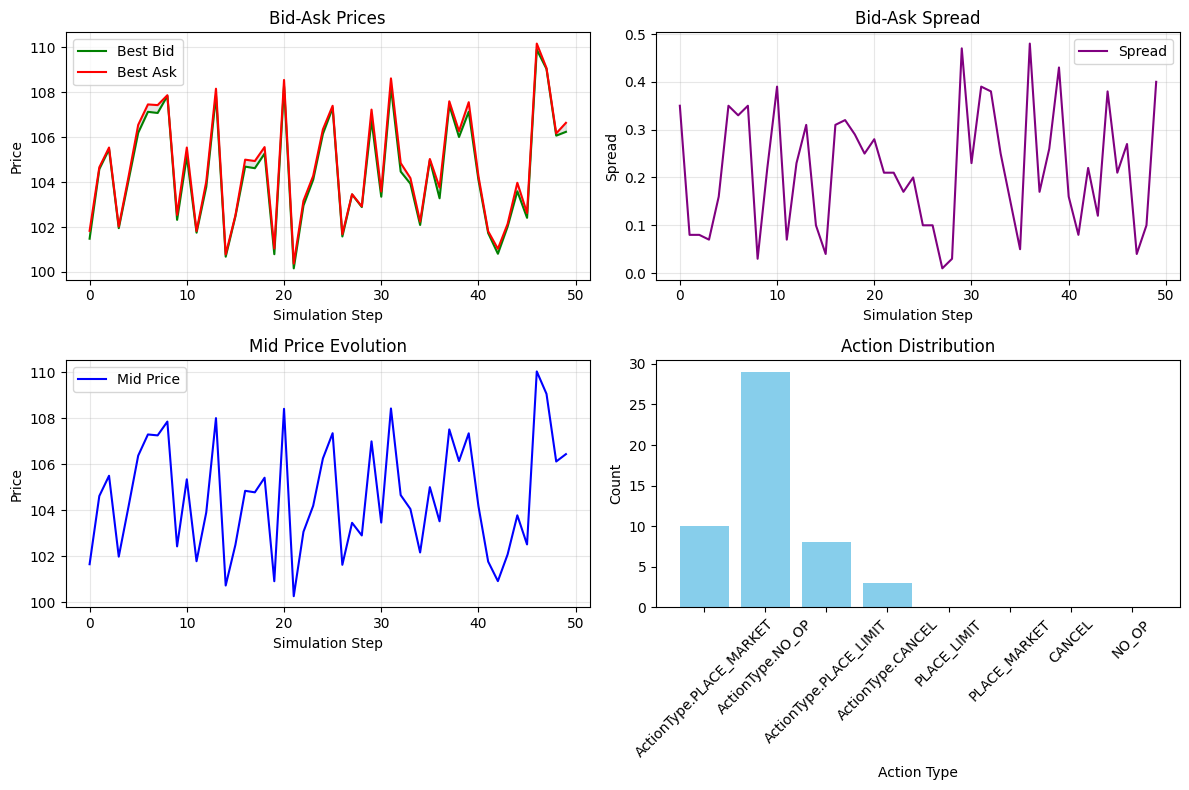

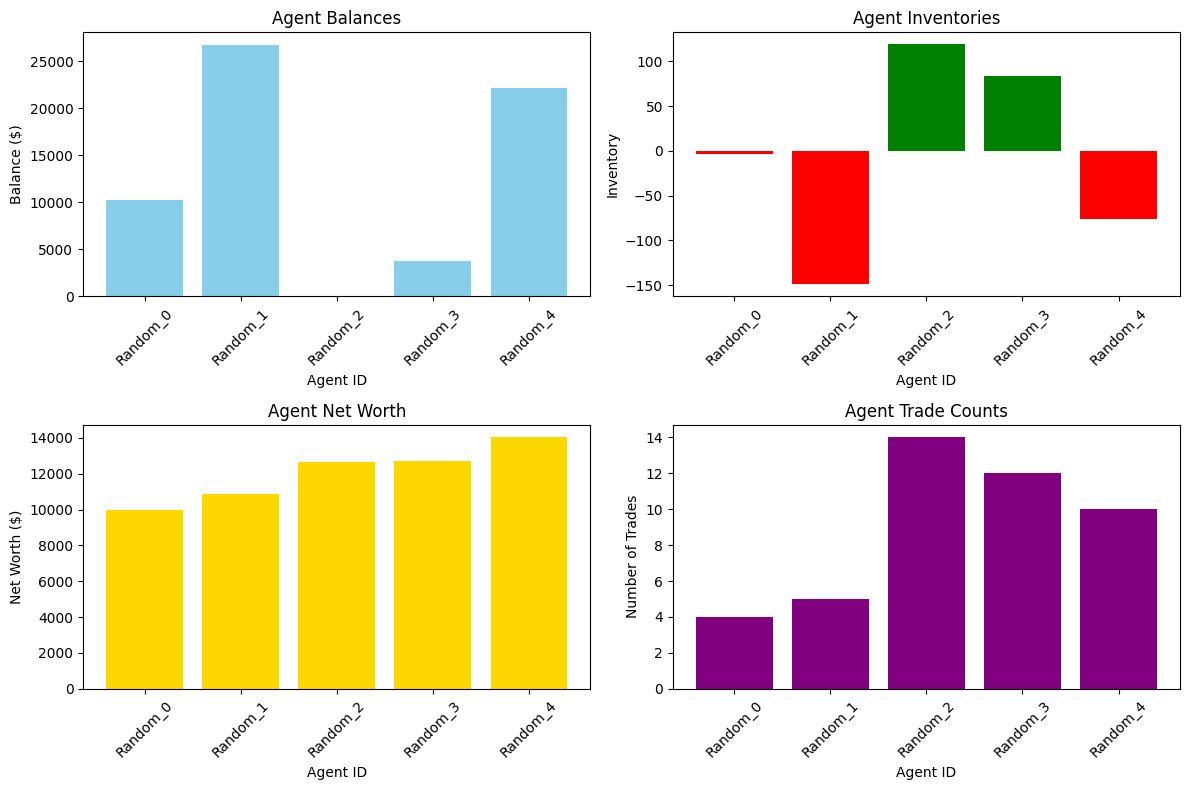


8. Analyzing Agent Behavior...
Action distribution for agent Random_0:
  ActionType.NO_OP: 39 actions (78.0%)
  ActionType.PLACE_MARKET: 4 actions (8.0%)
  ActionType.PLACE_LIMIT: 5 actions (10.0%)
  ActionType.CANCEL: 2 actions (4.0%)

Timing analysis:
  Total actions: 50
  Average interval: 1.00 steps
  Std dev interval: 0.00 steps
  Min interval: 1.00 steps
  Max interval: 1.00 steps

DEMONSTRATION COMPLETE


In [35]:
def run_complete_demo():
    """Run a complete demonstration of the agent architecture"""
    print("=" * 80)
    print("DAY 6: AGENT ARCHITECTURE DEMONSTRATION")
    print("=" * 80)
    print("\n1. Creating Agent Registry...")

    # Create registry
    registry = AgentRegistry()

    print("\n2. Creating Random Agents...")
    # Create multiple random agents with different parameters
    agents = []
    for i in range(5):
        try:
            agent = RandomAgent(f"Random_{i}",
                              initial_balance=10000.0 + i * 1000,
                              action_probability=0.2 + 0.1 * i,
                              position_limit=500 + i * 100)
            agents.append(agent)
            print(f"  Created: {agent}")
        except Exception as e:
            print(f"  Error creating agent Random_{i}: {e}")

    # Register all agents
    for agent in agents:
        try:
            registry.register_agent(agent)
            print(f"  Registered: {agent.id}")
        except Exception as e:
            print(f"  Error registering agent {agent.id}: {e}")

    print(f"\n3. Agent Registry Stats:")
    stats = registry.get_agent_stats()
    print(f"  Total agents: {stats['total_agents']}")
    print(f"  Agent types: {stats['agent_type_distribution']}")
    print(f"  Total balance in system: ${stats['total_balance']:.2f}")

    if stats['total_agents'] == 0:
        print("\nERROR: No agents registered. Cannot run simulation.")
        return None, None

    print("\n4. Creating Market Simulator...")
    simulator = MarketSimulator(registry)

    print("\n5. Running Simulation (50 steps)...")
    try:
        results = simulator.run_simulation(steps=50)
        print(f"   Simulation completed successfully!")
        print(f"   Total steps: {len(results['steps'])}")

        # Safely count total actions
        total_actions = 0
        if 'action_summary' in results:
            total_actions = sum(results['action_summary'].values())
        print(f"   Total actions: {total_actions}")

        if total_actions > 0:
            print(f"\n   Action Summary:")
            for action_type, count in results.get('action_summary', {}).items():
                print(f"     {action_type}: {count}")
        else:
            print(f"\n   No actions recorded in simulation")

    except Exception as e:
        print(f"\nERROR during simulation: {e}")
        import traceback
        traceback.print_exc()
        return simulator, None

    print("\n6. Agent Performance Summary:")
    agent_performance = results.get('agent_performance', {})
    if agent_performance:
        for agent_id, perf in agent_performance.items():
            print(f"\n   Agent: {agent_id}")
            print(f"     Balance: ${perf.get('balance', 0):.2f}")
            print(f"     Inventory: {perf.get('inventory', 0)}")
            print(f"     Trades: {perf.get('total_trades', 0)}")
            print(f"     Volume: {perf.get('total_volume', 0)}")
    else:
        print("   No performance data available")

    print("\n7. Generating Visualizations...")
    try:
        # Check if we have enough data for visualization
        if results and 'market_metrics' in results and len(results['market_metrics']) > 0:
            AgentAnalysis.plot_market_evolution(results)
        else:
            print("   Not enough market data for visualization")

        if agent_performance:
            AgentAnalysis.plot_agent_performance(agent_performance)
        else:
            print("   Not enough agent performance data for visualization")

    except Exception as e:
        print(f"   Error generating visualizations: {e}")
        import traceback
        traceback.print_exc()

    print("\n8. Analyzing Agent Behavior...")
    if agent_performance and simulator.action_log:
        # Analyze the first agent that has actions
        for agent_id in agent_performance.keys():
            if any(log.get('agent_id') == agent_id for log in simulator.action_log):
                AgentAnalysis.analyze_agent_behavior(simulator.action_log, agent_id)
                break
    else:
        print("   No agent behavior data available for analysis")

    print("\n" + "=" * 80)
    print("DEMONSTRATION COMPLETE")
    print("=" * 80)

    return simulator, results

# Run the demo
simulator, results = run_complete_demo()

## 2. Validation Tests

In [36]:
import unittest

class TestAgentArchitecture(unittest.TestCase):
    """Comprehensive tests for the agent architecture"""

    def test_abstract_base_class(self):
        """Test that Agent is truly abstract"""
        with self.assertRaises(TypeError):
            # Cannot instantiate abstract class
            agent = Agent("test_agent")

    def test_random_agent_creation(self):
        """Test RandomAgent instantiation"""
        agent = RandomAgent("test_random", initial_balance=10000.0)
        self.assertEqual(agent.id, "test_random")
        self.assertEqual(agent.balance, 10000.0)
        self.assertEqual(agent.inventory, 0)

    def test_polymorphism(self):
        """Test that all agents implement the required interface"""
        agents = [
            RandomAgent("random_1"),
        ]

        for agent in agents:
            # All agents should have get_action method
            self.assertTrue(hasattr(agent, 'get_action'))
            self.assertTrue(callable(agent.get_action))

            # All agents should have required properties
            self.assertTrue(hasattr(agent, 'id'))
            self.assertTrue(hasattr(agent, 'balance'))
            self.assertTrue(hasattr(agent, 'inventory'))

    def test_market_snapshot_validation(self):
        """Test market snapshot validation"""
        # Valid snapshot
        level1 = Level1Data(
            timestamp=0.0,
            best_bid=100.0,
            best_ask=100.1,
            bid_quantity=100,
            ask_quantity=100
        )

        snapshot = MarketSnapshot(
            timestamp=0.0,
            level1=level1
        )

        self.assertEqual(snapshot.level1.spread, 0.1)
        self.assertEqual(snapshot.level1.mid_price, 100.05)

        # Invalid snapshot (bid >= ask)
        level1_invalid = Level1Data(
            timestamp=0.0,
            best_bid=100.0,
            best_ask=99.9,  # Less than bid!
            bid_quantity=100,
            ask_quantity=100
        )

        with self.assertRaises(ValueError):
            MarketSnapshot(timestamp=0.0, level1=level1_invalid)

    def test_action_validation(self):
        """Test action validation"""
        # Valid limit order
        limit_order = PlaceLimitOrder(
            agent_id="test_agent",
            timestamp=0.0,
            side=OrderSide.BUY,
            price=100.0,
            quantity=10
        )

        self.assertEqual(limit_order.action_type, ActionType.PLACE_LIMIT)

        # Invalid limit order (negative price)
        with self.assertRaises(ValueError):
            PlaceLimitOrder(
                agent_id="test_agent",
                timestamp=0.0,
                side=OrderSide.BUY,
                price=-100.0,
                quantity=10
            )

    def test_agent_constraints(self):
        """Test that agents respect constraints"""
        agent = RandomAgent(
            "test_agent",
            initial_balance=1000.0,
            position_limit=100
        )

        # Generate many actions to test constraints
        snapshot = MarketSnapshot(
            timestamp=0.0,
            level1=Level1Data(
                timestamp=0.0,
                best_bid=100.0,
                best_ask=100.1,
                bid_quantity=100,
                ask_quantity=100
            )
        )

        actions = []
        for _ in range(1000):
            action = agent.get_action(snapshot)
            actions.append(action)

            # If it's a buy limit order, check price constraint
            if isinstance(action, PlaceLimitOrder) and action.side == OrderSide.BUY:
                self.assertLessEqual(action.price, snapshot.level1.best_bid)

            # If it's a sell limit order, check price constraint
            if isinstance(action, PlaceLimitOrder) and action.side == OrderSide.SELL:
                self.assertGreaterEqual(action.price, snapshot.level1.best_ask)

    def test_registry_functionality(self):
        """Test agent registry"""
        registry = AgentRegistry()

        # Register agents
        agent1 = RandomAgent("agent1")
        agent2 = RandomAgent("agent2")

        registry.register_agent(agent1)
        registry.register_agent(agent2)

        self.assertEqual(len(registry.get_all_agents()), 2)

        # Get agent
        retrieved = registry.get_agent("agent1")
        self.assertEqual(retrieved.id, "agent1")

        # Unregister
        registry.unregister_agent("agent1")
        self.assertEqual(len(registry.get_all_agents()), 1)

        # Should raise error for non-existent agent
        with self.assertRaises(KeyError):
            registry.get_agent("agent1")

    def test_simulation_invariants(self):
        """Test that simulation maintains invariants"""
        registry = AgentRegistry()
        agent = RandomAgent("test_agent", initial_balance=10000.0)
        registry.register_agent(agent)

        simulator = MarketSimulator(registry)

        # Run a few steps
        for _ in range(10):
            step_result = simulator.run_simulation_step()

            # Check that all actions have valid timestamps
            for agent_id, action in step_result['agent_actions'].items():
                self.assertEqual(action.timestamp, step_result['timestamp'])
                self.assertEqual(action.agent_id, agent_id)

            # Check market data validity
            snapshot = step_result['market_snapshot']
            self.assertGreater(snapshot.level1.best_ask, snapshot.level1.best_bid)
            self.assertGreater(snapshot.level1.spread, 0)

    def test_performance_tracking(self):
        """Test agent performance tracking"""
        agent = RandomAgent("test_agent", initial_balance=10000.0)

        # Simulate some trades
        agent.record_trade({
            'side': 'BUY',
            'price': 100.0,
            'quantity': 10,
            'value': 1000.0
        })

        agent.update_inventory(10)
        agent.update_balance(-1000.0)

        metrics = agent.get_performance_metrics()

        self.assertEqual(metrics['total_trades'], 1)
        self.assertEqual(metrics['total_volume'], 10)
        self.assertEqual(metrics['inventory'], 10)
        self.assertEqual(metrics['balance'], 9000.0)

    def test_reset_functionality(self):
        """Test agent reset functionality"""
        agent = RandomAgent("test_agent", initial_balance=10000.0)

        # Change state
        agent.update_inventory(10)
        agent.update_balance(-1000.0)
        agent.record_trade({'side': 'BUY', 'price': 100.0, 'quantity': 10, 'value': 1000.0})

        # Reset
        agent.reset(5000.0)

        self.assertEqual(agent.balance, 5000.0)
        self.assertEqual(agent.inventory, 0)
        self.assertEqual(len(agent._trade_history), 0)
        self.assertEqual(len(agent._action_history), 0)

# Run tests
def run_tests():
    """Run all validation tests"""
    print("Running validation tests...")
    print("-" * 60)

    test_suite = unittest.TestLoader().loadTestsFromTestCase(TestAgentArchitecture)
    test_runner = unittest.TextTestRunner(verbosity=2)
    result = test_runner.run(test_suite)

    print("\n" + "=" * 60)
    print(f"Tests run: {result.testsRun}")
    print(f"Failures: {len(result.failures)}")
    print(f"Errors: {len(result.errors)}")

    if result.wasSuccessful():
        print("✓ All tests passed!")
    else:
        print("✗ Some tests failed.")

    return result

# Run the tests
test_result = run_tests()

test_abstract_base_class (__main__.TestAgentArchitecture.test_abstract_base_class)
Test that Agent is truly abstract ... ok
test_action_validation (__main__.TestAgentArchitecture.test_action_validation)
Test action validation ... ERROR
test_agent_constraints (__main__.TestAgentArchitecture.test_agent_constraints)
Test that agents respect constraints ... ok
test_market_snapshot_validation (__main__.TestAgentArchitecture.test_market_snapshot_validation)
Test market snapshot validation ... FAIL
test_performance_tracking (__main__.TestAgentArchitecture.test_performance_tracking)
Test agent performance tracking ... ok
test_polymorphism (__main__.TestAgentArchitecture.test_polymorphism)
Test that all agents implement the required interface ... ok
test_random_agent_creation (__main__.TestAgentArchitecture.test_random_agent_creation)
Test RandomAgent instantiation ... ok
test_registry_functionality (__main__.TestAgentArchitecture.test_registry_functionality)
Test agent registry ... ok
test_res

Running validation tests...
------------------------------------------------------------

Tests run: 10
Failures: 1
Errors: 1
✗ Some tests failed.


## 3. Advanced Agent Examples

In [37]:
class MarketMakerAgent(Agent):
    """
    Simple Market Maker Agent

    Strategy:
    - Continuously quotes both bid and ask
    - Adjusts quotes based on inventory
    - Manages risk through position limits
    """

    def __init__(self, agent_id: str, initial_balance: float = 10000.0,
                 spread_target: float = 0.1, inventory_target: int = 0):
        super().__init__(agent_id, initial_balance)
        self.spread_target = spread_target
        self.inventory_target = inventory_target
        self.quote_size = 100  # Default quote size
        self.max_position = 1000  # Maximum position size

    def get_action(self, market_snapshot: MarketSnapshot) -> Action:
        """Implement market making logic"""
        # Calculate desired quotes
        mid_price = market_snapshot.level1.mid_price
        inventory_imbalance = self.inventory - self.inventory_target

        # Adjust quotes based on inventory
        # If long, lower bids and raises offers to reduce position
        # If short, raise bids and lower offers to reduce position
        inventory_adjustment = inventory_imbalance * 0.001  # Small adjustment

        desired_bid = mid_price - self.spread_target/2 - inventory_adjustment
        desired_ask = mid_price + self.spread_target/2 - inventory_adjustment

        # Round to tick size
        tick_size = 0.01
        desired_bid = round(desired_bid / tick_size) * tick_size
        desired_ask = round(desired_ask / tick_size) * tick_size

        # Cancel existing orders if needed
        if self._open_orders:
            # Simple logic: cancel all and replace
            order_id = next(iter(self._open_orders))
            return CancelOrder(
                action_type=ActionType.CANCEL,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp,
                order_id=order_id
            )

        # Place new quotes
        # For simplicity, alternate between bid and ask
        if len(self._open_orders) == 0:
            # Place bid
            return PlaceLimitOrder(
                action_type=ActionType.PLACE_LIMIT,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp,
                side=OrderSide.BUY,
                price=desired_bid,
                quantity=self.quote_size
            )
        elif len(self._open_orders) == 1:
            # Place ask
            return PlaceLimitOrder(
                action_type=ActionType.PLACE_LIMIT,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp,
                side=OrderSide.SELL,
                price=desired_ask,
                quantity=self.quote_size
            )
        else:
            return NoOp(
                action_type=ActionType.NO_OP,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp
            )

class TrendFollowingAgent(Agent):
    """
    Simple Trend Following Agent

    Strategy:
    - Tracks price momentum
    - Buys when price is rising
    - Sells when price is falling
    - Uses simple moving average
    """

    def __init__(self, agent_id: str, initial_balance: float = 10000.0,
                 lookback: int = 5, position_size: int = 10):
        super().__init__(agent_id, initial_balance)
        self.lookback = lookback
        self.position_size = position_size
        self.price_history = []
        self.position = 0  # 1 for long, -1 for short, 0 for flat

    def get_action(self, market_snapshot: MarketSnapshot) -> Action:
        """Implement trend following logic"""
        current_price = market_snapshot.level1.mid_price
        self.price_history.append(current_price)

        # Keep only recent history
        if len(self.price_history) > self.lookback * 2:
            self.price_history = self.price_history[-self.lookback * 2:]

        if len(self.price_history) < self.lookback:
            return NoOp(
                action_type=ActionType.NO_OP,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp
            )

        # Calculate simple moving averages
        short_window = min(self.lookback, len(self.price_history) // 2)
        long_window = min(self.lookback * 2, len(self.price_history))

        short_ma = np.mean(self.price_history[-short_window:])
        long_ma = np.mean(self.price_history[-long_window:])

        # Trading signal
        if short_ma > long_ma * 1.001 and self.position <= 0:
            # Bullish signal, go long
            self.position = 1
            return PlaceMarketOrder(
                action_type=ActionType.PLACE_MARKET,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp,
                side=OrderSide.BUY,
                quantity=self.position_size
            )
        elif short_ma < long_ma * 0.999 and self.position >= 0:
            # Bearish signal, go short
            self.position = -1
            return PlaceMarketOrder(
                action_type=ActionType.PLACE_MARKET,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp,
                side=OrderSide.SELL,
                quantity=self.position_size
            )
        else:
            return NoOp(
                action_type=ActionType.NO_OP,
                agent_id=self.id,
                timestamp=market_snapshot.timestamp
            )

def demonstrate_agent_zoo():
    """Demonstrate multiple agent types working together"""
    print("Creating Agent Zoo with Multiple Agent Types...")
    print("-" * 60)

    registry = AgentRegistry()

    # Create diverse agents
    agents = [
        RandomAgent("Random_1", action_probability=0.3),
        RandomAgent("Random_2", action_probability=0.5),
        MarketMakerAgent("MarketMaker_1", spread_target=0.2),
        TrendFollowingAgent("TrendFollower_1", lookback=3),
        TrendFollowingAgent("TrendFollower_2", lookback=5),
    ]

    for agent in agents:
        registry.register_agent(agent)
        print(f"Registered: {agent.__class__.__name__} - {agent.id}")

    print(f"\nTotal agents: {len(registry.get_all_agents())}")

    # Run simulation
    simulator = MarketSimulator(registry)
    results = simulator.run_simulation(steps=50)

    print("\nSimulation Results:")
    print("-" * 40)

    # Show agent diversity
    stats = registry.get_agent_stats()
    print(f"Agent types: {stats['agent_type_distribution']}")

    # Show performance by agent type
    agent_performance = results['agent_performance']

    print("\nPerformance by Agent Type:")
    for agent_id, perf in agent_performance.items():
        agent_type = agent_id.split('_')[0]
        print(f"{agent_type}: Net Worth = ${perf['net_worth']:.2f}, Trades = {perf['total_trades']}")

    return simulator, results

# Run the agent zoo demonstration
zoo_simulator, zoo_results = demonstrate_agent_zoo()

Creating Agent Zoo with Multiple Agent Types...
------------------------------------------------------------
Registered: RandomAgent - Random_1
Registered: RandomAgent - Random_2
Registered: MarketMakerAgent - MarketMaker_1
Registered: TrendFollowingAgent - TrendFollower_1
Registered: TrendFollowingAgent - TrendFollower_2

Total agents: 5
Error getting action from agent MarketMaker_1: PlaceLimitOrder.__init__() missing 1 required positional argument: 'order_id'
Error getting action from agent TrendFollower_1: name 'NoOp' is not defined
Error getting action from agent TrendFollower_2: name 'NoOp' is not defined
Error getting action from agent MarketMaker_1: PlaceLimitOrder.__init__() missing 1 required positional argument: 'order_id'
Error getting action from agent TrendFollower_1: name 'NoOp' is not defined
Error getting action from agent TrendFollower_2: name 'NoOp' is not defined
Error getting action from agent MarketMaker_1: PlaceLimitOrder.__init__() missing 1 required positional a